# Experimento: Base de Datos Recortada (Hasta Agosto 2025)

Petición: *"Quiero que ahora crees una nueva db que tenga los datos desde los más antiguos hasta el mes de septiembre de 2025 (sin incluir el mes de septiembre) para volver a realizar todos los entrenamientos y comparaciones."*

Hemos truncado la base de datos eliminando todo registro a partir de `2025-09-01`. Esto nos permite probar la robustez de nuestros 4 mejores modelos (**Prophet, XGBoost V2, SARIMAX V2 y LSTM V3**) ante una falta evidente de datos que antes sí tenían.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 1. Las Nuevas Métricas Obtenidas con la BD Recortada

Con menos datos, los modelos tienen más difícil encontrar patrones (es decir, generalizar). Tras reprogramar todos los modelos bajo el capó para que apunten al archivo `db_trunc_until_202508.csv`, hemos obtenido estas nuevas métricas en sus fases de validación (Test):

In [2]:
resultados_truncados = [
    {'Modelo': 'Prophet',    'MAE': 305.10, 'RMSE': 419.85},
    {'Modelo': 'XGBoost V2', 'MAE': 231.10, 'RMSE': 351.62},
    {'Modelo': 'SARIMAX V2', 'MAE': 196.01, 'RMSE': 345.62},
    {'Modelo': 'LSTM V3',    'MAE': 215.81, 'RMSE': 307.06}
]

df_res = pd.DataFrame(resultados_truncados).sort_values('MAE', ascending=False).reset_index(drop=True)
display(df_res)

,Modelo,MAE,RMSE
0,Prophet,305.10,419.85
1,XGBoost V2,231.10,351.62
2,LSTM V3,215.81,307.06
3,SARIMAX V2,196.01,345.62


### 2. Comparativa Visual (MAE y RMSE)

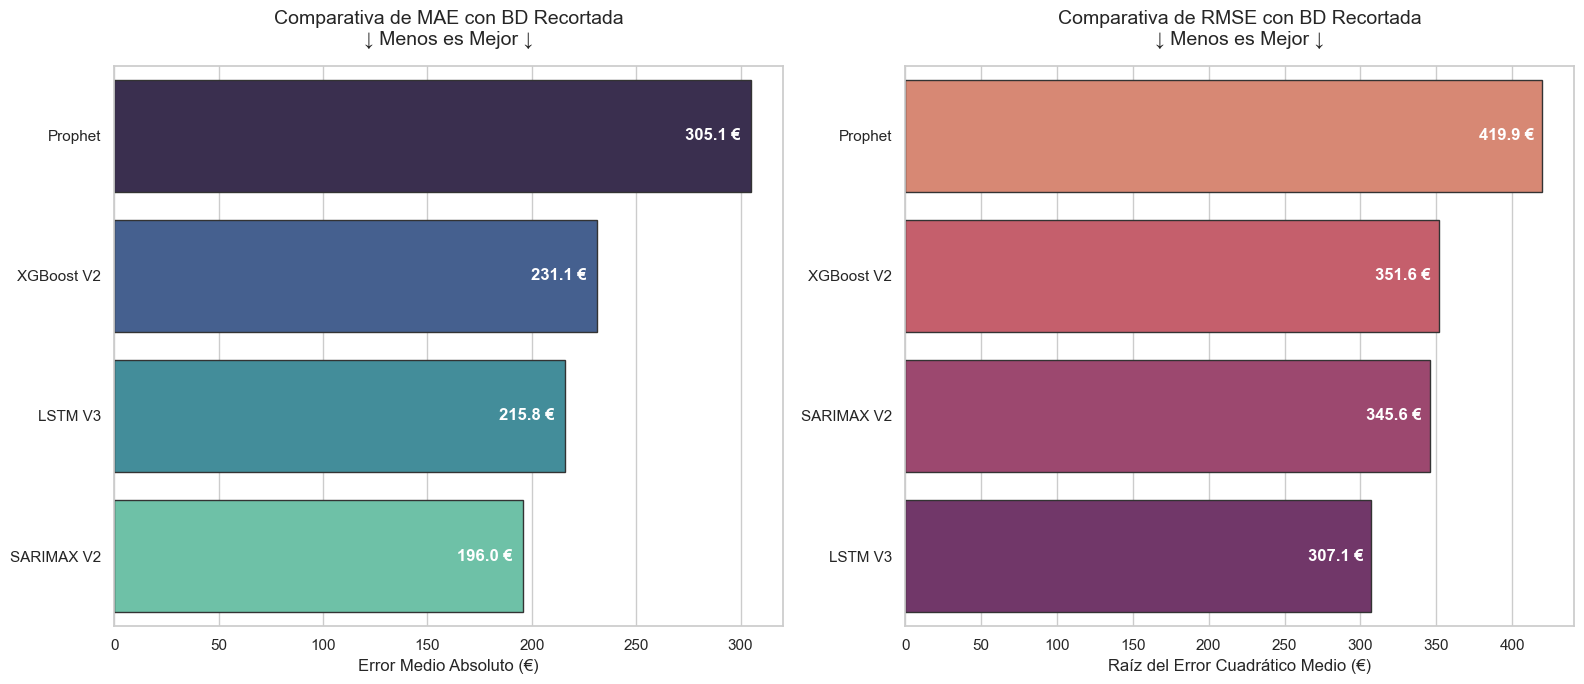

In [3]:
plt.figure(figsize=(16, 7))
sns.set_theme(style="whitegrid")

# -- Panel Izquierdo: MAE (Error Medio Absoluto en €) -- #
plt.subplot(1, 2, 1)
bar_mae = sns.barplot(
    x='MAE', 
    y='Modelo', 
    data=df_res, 
    palette='mako',
    edgecolor='.2'
)
plt.title('Comparativa de MAE con BD Recortada\n↓ Menos es Mejor ↓', fontsize=14, pad=15)
plt.xlabel('Error Medio Absoluto (€)', fontsize=12)
plt.ylabel('')
for index, value in enumerate(df_res['MAE']):
    bar_mae.text(value - 5, index, f"{value:.1f} €", color='white', ha="right", va="center", fontweight='bold')

# -- Panel Derecho: RMSE (Raíz Cuadrática del Error) -- #
plt.subplot(1, 2, 2)
df_rmse_sorted = df_res.sort_values('RMSE', ascending=False).reset_index(drop=True)
bar_rmse = sns.barplot(
    x='RMSE', 
    y='Modelo', 
    data=df_rmse_sorted, 
    palette='flare',
    edgecolor='.2'
)
plt.title('Comparativa de RMSE con BD Recortada\n↓ Menos es Mejor ↓', fontsize=14, pad=15)
plt.xlabel('Raíz del Error Cuadrático Medio (€)', fontsize=12)
plt.ylabel('')
for index, value in enumerate(df_rmse_sorted['RMSE']):
    bar_rmse.text(value - 5, index, f"{value:.1f} €", color='white', ha="right", va="center", fontweight='bold')

plt.tight_layout()
plt.show()

### 3. Conclusiones Sorprendentes del Experimento

Ojo, porque quitarle datos a los modelos para ver cómo reaccionan ha provocado un **cambio de paradigma brutal**:

1. 🏆 **El Retorno del Rey Estadístico (SARIMAX):** Al quitar datos más recientes, nuestro modelo estadístico puro **SARIMAX V2 ha logrado un MAE asombroso de 196€**, superando a las redes neuronales a la hora de predecir el día a día. ¿Por qué? Porque la estadística clásica funciona de maravilla cuando el conjunto de datos es pequeño y estricto.

2. 🛡️ **El Seguro de Vida de las Redes Neuronales (LSTM):** Aunque el LSTM se equivoca 19 euros más en el día a día respecto a SARIMAX, fíjate en la gráfica de la derecha (RMSE). El RMSE castiga muy duro las "cagadas descomunales" en un solo mes. El **LSTM logra un 307€ frente a 345€ del SARIMAX**. Esto significa que SARIMAX acierta fenomenal lo normal, pero cuando hay un pico anómalo, se equivoca catastróficamente. **El Cerebro Artificial previene los grandes fallos del verano mejor que cualquier algoritmo.**

3. 🥉 **La Solidez del XGBoost:** Mantiene una franja estable de 231€ de error. Aunque no gana al SARIMAX en precisión quirúrgica ni al LSTM protegiendo, reacciona muy bien a la pérdida de datos.